In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs("visuals", exist_ok=True)

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

In [3]:
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [4]:
df["average score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

In [5]:
print("\nAverage Scores:")
print(df[["math score", "reading score", "writing score"]].mean())


Average Scores:
math score       66.089
reading score    69.169
writing score    68.054
dtype: float64


In [6]:
print("\nMax Scores:")
print(df[["math score", "reading score", "writing score"]].max())


Max Scores:
math score       100
reading score    100
writing score    100
dtype: int64


In [7]:
print("\nMin Scores:")
print(df[["math score", "reading score", "writing score"]].min())


Min Scores:
math score        0
reading score    17
writing score    10
dtype: int64


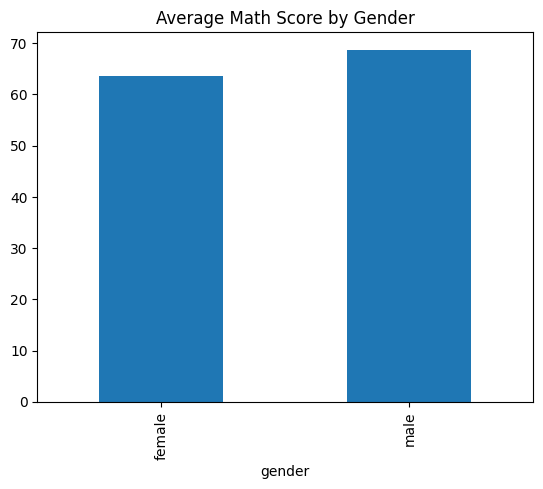

In [8]:
gender_scores = df.groupby("gender")["math score"].mean()
gender_scores.plot(kind="bar")
plt.title("Average Math Score by Gender")
plt.savefig("visuals/math_score_gender.png")
plt.show()
        

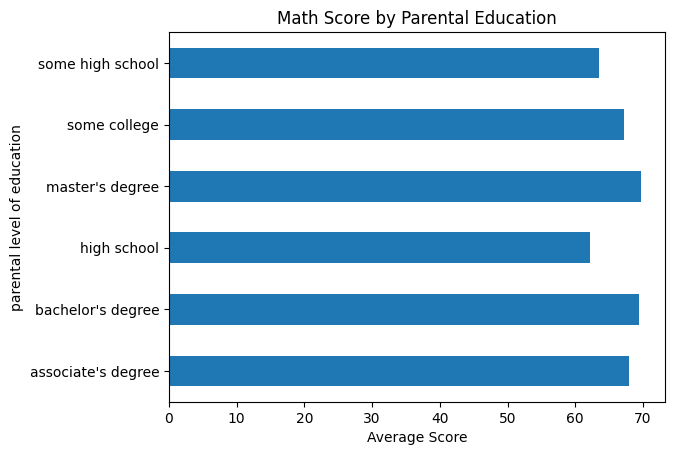

In [9]:
edu_scores = df.groupby("parental level of education")["math score"].mean()

edu_scores.plot(kind="barh")
plt.title("Math Score by Parental Education")
plt.xlabel("Average Score")
plt.savefig("visuals/parent_education.png")
plt.show()

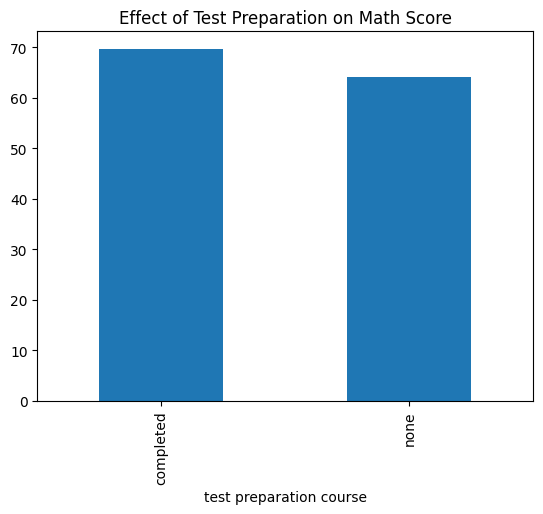

In [10]:
prep_scores = df.groupby("test preparation course")["math score"].mean()

prep_scores.plot(kind="bar")
plt.title("Effect of Test Preparation on Math Score")
plt.savefig("visuals/test_prep.png")
plt.show()

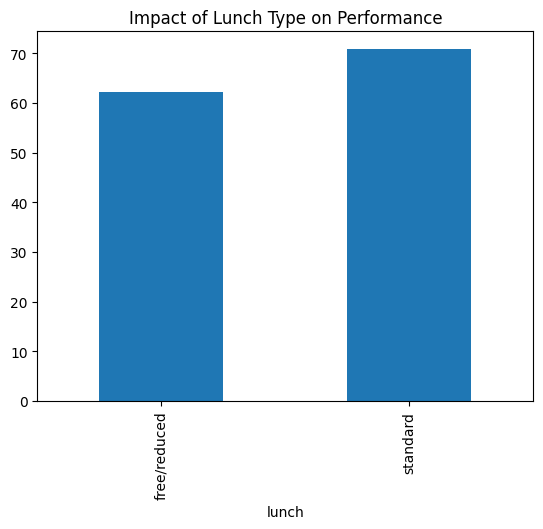

In [11]:
df.groupby("lunch")["average score"].mean().plot(kind="bar")
plt.title("Impact of Lunch Type on Performance")
plt.savefig("visuals/lunch_effect.png")
plt.show()

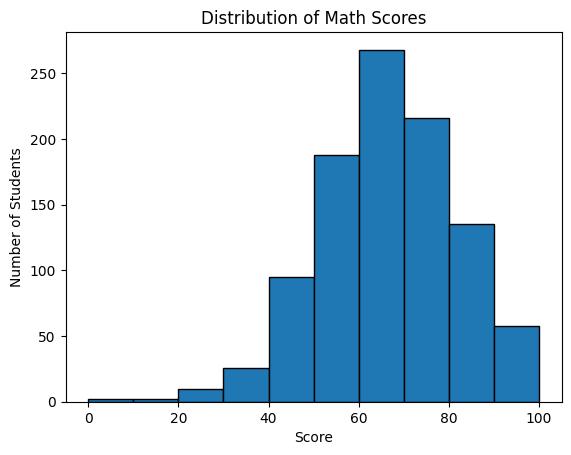

In [12]:
plt.hist(df["math score"], bins=10, edgecolor="black")
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.savefig("visuals/math_distribution.png")
plt.show()

In [13]:
top10 = df.sort_values("average score", ascending=False).head(10)
print(top10[["gender", "math score", "reading score", "writing score", "average score"]])

     gender  math score  reading score  writing score  average score
962  female         100            100            100     100.000000
458  female         100            100            100     100.000000
916    male         100            100            100     100.000000
114  female          99            100            100      99.666667
179  female          97            100            100      99.000000
712  female          98            100             99      99.000000
165  female          96            100            100      98.666667
625    male         100             97             99      98.666667
149    male         100            100             93      97.666667
685  female          94             99            100      97.666667
